In [1]:
#Imports and directory
import os
import pickle
import random
import math
import numpy as np
import pandas as pd
import matplotlib
import torch
import torch.nn as nn
import optuna
from matplotlib import pyplot as plt
from pandas import Period
os.chdir("/home/ec2-user/CS-230-Deep-Learning-Project")
#os.chdir(r"C:\Users\gotta\OneDrive\Documents\Bureau\X\4A\US\Stanford\Classes\CS 230\Project\CS-230-Deep-Learning-Project")

/opt/pytorch/lib/python3.12/site-packages/torch/cuda/__init__.py:63: FutureWarning: The pynvml package is deprecated. Please install nvidia-ml-py instead. If you did not install pynvml directly, please report this to the maintainers of the package that installed pynvml for you.
  import pynvml  # type: ignore[import]


In [2]:
# Basic functions including device and seeding
device = 'cuda:0' if torch.cuda.is_available() else 'cpu'
print("USING DEVICE:", device)

def save_object_to_file(obj, filepath):
    with open(filepath, "wb") as f:
        pickle.dump(obj, f)

def read_object_from_file(filepath):
    with open(filepath, "rb") as f:
        return pickle.load(f)

def seed_everything(seed):
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    np.random.seed(seed)
    random.seed(seed)
    os.environ['PYTHONHASHSEED'] = str(seed)
    torch.backends.cudnn.benchmark = False
    torch.backends.cudnn.deterministic = True


USING DEVICE: cuda:0


In [3]:
# --- Data preparation ---
DATA_CSV_FR = os.path.join("data", "FR_price", "FR_lmp_processed.csv")
DATA_CSV_LOAD = os.path.join("data", "FR_DAM_Load", "FR_load_processed.csv")
DATA_CSV_REN = os.path.join("data", "FR_REN", "FR_ren_processed.csv")
DATA_CSV_LOAD_RT=os.path.join("data", "FR_DAM_Load", "FR_rt_load_processed.csv")
DATA_CSV_REN_RT=os.path.join("data", "FR_REN", "FR_rt_ren_processed.csv")


In [4]:
df_FR = pd.read_csv(DATA_CSV_FR)
load_FR = pd.read_csv(DATA_CSV_LOAD)
ren_FR = pd.read_csv(DATA_CSV_REN)
all_data_DA = pd.merge(df_FR, load_FR, on=['Time', 'Timezone', 'Year', 'Month', 'Day', 'Hour'], how='inner')
all_data_DA = pd.merge(all_data_DA, ren_FR, on=['Time', 'Timezone', 'Year', 'Month', 'Day', 'Hour'], how='inner')
all_data_DA.rename(columns={'MW':'Load_DA','Wind Onshore':'Wind_DA','Solar':'Solar_DA'}, inplace=True)
load_FR_rt = pd.read_csv(DATA_CSV_LOAD_RT)
ren_FR_rt = pd.read_csv(DATA_CSV_REN_RT)
all_data_RT = pd.merge(df_FR, load_FR_rt, on=['Time', 'Timezone', 'Year', 'Month', 'Day', 'Hour'], how='inner')
all_data_RT = pd.merge(all_data_RT, ren_FR_rt, on=['Time', 'Timezone', 'Year', 'Month', 'Day', 'Hour'], how='inner')
all_data_RT.rename(columns={'MW':'Load_RT','Wind Onshore':'Wind_RT','Solar':'Solar_RT'}, inplace=True)

all_data=pd.merge(all_data_DA,all_data_RT,on=['Time', 'Timezone', 'Year', 'Month', 'Day', 'Hour','EUR/MWh'], how='inner')
all_data

,Time,Year,Month,Day,Hour,Timezone,EUR/MWh,Load_DA,Wind_DA,Solar_DA,Load_RT,Wind_RT,Solar_RT
0,2019-10-01 00:00:00+02:00,2019,10,1,0,+02:00,33.09,44450.0,4975.31,0.00,43062.00,6076.00,0.00
1,2019-10-01 01:00:00+02:00,2019,10,1,1,+02:00,27.72,41300.0,5338.58,0.00,40483.00,6137.00,0.00
2,2019-10-01 02:00:00+02:00,2019,10,1,2,+02:00,23.12,40050.0,5702.33,0.00,39207.00,6342.00,0.00
3,2019-10-01 03:00:00+02:00,2019,10,1,3,+02:00,16.46,37750.0,5667.94,0.00,37004.00,6355.00,0.00
4,2019-10-01 04:00:00+02:00,2019,10,1,4,+02:00,15.66,36600.0,5633.30,0.00,36399.00,6217.00,0.00
...,...,...,...,...,...,...,...,...,...,...,...,...,...
52142,2025-09-30 19:00:00+02:00,2025,9,30,19,+02:00,117.00,49000.0,2435.69,2158.72,49421.41,1939.43,901.85
52143,2025-09-30 20:00:00+02:00,2025,9,30,20,+02:00,106.18,50400.0,2929.19,315.89,50315.77,2445.66,244.45
52144,2025-09-30 21:00:00+02:00,2025,9,30,21,+02:00,83.23,46700.0,3480.47,0.00,47039.08,3116.56,0.00
52145,2025-09-30 22:00:00+02:00,2025,9,30,22,+02:00,73.00,44100.0,3879.11,0.00,45544.52,3422.12,0.00


In [5]:
#Convert hour, day, month into cyclic features
def add_cyclical_features(df):
    df['Date']=pd.to_datetime(df[['Year', 'Month', 'Day', 'Hour']])
    df["DayOfWeek"] = df['Date'].dt.dayofweek
    # Hour of day (0-23)
    df["sin_hour"] = np.sin(2 * np.pi * df["Hour"] / 24)
    df["cos_hour"] = np.cos(2 * np.pi * df["Hour"] / 24)

    # Day of week (0-6 or 1-7 depending on your data)
    df["sin_day"] = np.sin(2 * np.pi * df["DayOfWeek"] / 7)
    df["cos_day"] = np.cos(2 * np.pi * df["DayOfWeek"] / 7)

    # Month (1-12)
    df["sin_month"] = np.sin(2 * np.pi * df["Month"] / 12)
    df["cos_month"] = np.cos(2 * np.pi * df["Month"] / 12)
    return df
all_data = add_cyclical_features(all_data)


In [6]:
def create_sliding_window(data_df, string, window_days=7, forecast_horizon=1):
    """
    Outputs five DataFrames:
    - X_df: past window (arrays) + date
    - y_df: target next-day (arrays) + date
    - y_day_df: previous-day same-hour baseline + date
    - y_week_df: previous-week same-hour baseline + date
    - pct_df: percent change vs last window value + date
    """


    series = data_df[string].values
    dates = pd.to_datetime(data_df["Date"])

    hours_per_day = 24
    window_size = window_days * hours_per_day
    eps = 1e-6

    X, y = [], []
    y_day_before, y_week_before = [], []
    y_pct = []
    y_dates = []

    n = len(series)

    for i in range(0, n - window_size - forecast_horizon + 1):

        # Input window
        X_window = series[i : i + window_size]
        # Forecast target
        y_target = series[i + window_size : i + window_size + forecast_horizon]

        # Target date
        date_target = dates[i + window_size]

        # Previous-day baseline
        start_prev_day = i + window_size - hours_per_day
        if start_prev_day >= 0:
            prev_day = series[start_prev_day : start_prev_day + forecast_horizon]
        else:
            prev_day = np.full(forecast_horizon, np.nan)

        # Previous-week baseline
        start_prev_week = i + window_size - 7 * hours_per_day
        if start_prev_week >= 0:
            prev_week = series[start_prev_week : start_prev_week + forecast_horizon]
        else:
            prev_week = np.full(forecast_horizon, np.nan)

        # Percent change wrt last hour in window
        # pct = (y_target - X_window[-1]) / (X_window[-1] + eps)
        #scale=max(np.mean(X_window),eps)
        pct = (y_target - X_window[-1])

        # Append everything
        X.append(X_window.astype(np.float32))
        y.append(y_target.astype(np.float32))
        y_day_before.append(prev_day.astype(np.float32))
        y_week_before.append(prev_week.astype(np.float32))
        y_pct.append(pct.astype(np.float32))
        y_dates.append(date_target)

    # ---- Build DataFrames ----
    X_df = pd.DataFrame({string: X, "Date": y_dates})
    y_df = pd.DataFrame({"y": y, "Date": y_dates})
    y_day_df = pd.DataFrame({"y_day": y_day_before, "Date": y_dates})
    y_week_df = pd.DataFrame({"y_week": y_week_before, "Date": y_dates})
    pct_df = pd.DataFrame({"pct": y_pct, "Date": y_dates})

    return X_df, y_df, y_day_df, y_week_df, pct_df


In [7]:
#Create sliding windows
X_df, y_df, y_day_df, y_week_df, y_per_df   = create_sliding_window(all_data,'EUR/MWh', window_days=7, forecast_horizon=1)
Load_df, _, _, _, _ = create_sliding_window(all_data,'Load_RT', window_days=7, forecast_horizon=1)
Solar_df, _, _, _, _ = create_sliding_window(all_data,'Solar_RT', window_days=7, forecast_horizon=1)
Wind_df, _, _, _, _ = create_sliding_window(all_data,'Wind_RT', window_days=7, forecast_horizon=1)
cos_hour,_,_,_,_ = create_sliding_window(all_data,'cos_hour', window_days=7, forecast_horizon=1)
sin_hour,_,_,_,_ = create_sliding_window(all_data,'sin_hour', window_days=7, forecast_horizon=1)
cos_day,_,_,_,_ = create_sliding_window(all_data,'cos_day', window_days=7, forecast_horizon=1)
sin_day,_,_,_,_ = create_sliding_window(all_data,'sin_day', window_days=7, forecast_horizon=1)
cos_month,_,_,_,_ = create_sliding_window(all_data,'cos_month', window_days=7, forecast_horizon=1)
sin_month,_,_,_,_ = create_sliding_window(all_data,'sin_month', window_days=7, forecast_horizon=1)


In [8]:
#Sanity check on the 168th hour
# print("-------------")
# print("Sanity check on the 168th hour")
# print("The input X is:", X_df["Values"].iloc[0])
# print("The target y is:", y_df["Values"].iloc[0])
# print("The previous day y_day_before is:", y_day_df["Values"].iloc[0])
# print("The previous week y_week_before is:", y_week_df["Values"].iloc[0])
# print("The percentage change y_per is:", y_per_df["Values"].iloc[0])

# print("-------------")
# print("True Values at 2019-10-08 00:00 (168th hour)")
# print("The true data past 168 inputs are:", all_data['EUR/MWh'].values[0:168])
# print("The true target is:", all_data['EUR/MWh'].values[168:169])
# print("The true previous day prediction is:", all_data['EUR/MWh'].values[144:145])
# print("The true previous week is:", all_data['EUR/MWh'].values[0:1])
# print("The true percentage change is:", (all_data['EUR/MWh'].values[168:169]-all_data['EUR/MWh'].values[167:168])/(all_data['EUR/MWh'].values[167:168]+1e-9))

print("-------------")
print("Sanity check on inputs:", 
      np.allclose(X_df["EUR/MWh"].iloc[0], all_data['EUR/MWh'].values[0:168]))

print("Sanity check on target:", 
      np.allclose(y_df["y"].iloc[0], all_data['EUR/MWh'].values[168:169]))

print("Sanity check on previous day:", 
      np.allclose(y_day_df["y_day"].iloc[0], all_data['EUR/MWh'].values[144:145]))

print("Sanity check on previous week:", 
      np.allclose(y_week_df["y_week"].iloc[0], all_data['EUR/MWh'].values[0:1]))

print("Sanity check on percentage change:", 
      # np.allclose(y_per_df["pct"].iloc[0], (all_data['EUR/MWh'].values[168:169]-all_data['EUR/MWh'].values[167:168])/(all_data['EUR/MWh'].values[167:168]+1e-3)))
      np.allclose(y_per_df["pct"].iloc[0], (all_data['EUR/MWh'].values[168:169]-all_data['EUR/MWh'].values[167:168])))

-------------
Sanity check on inputs: True
Sanity check on target: True
Sanity check on previous day: True
Sanity check on previous week: True
Sanity check on percentage change: True


In [9]:
def dedupe(df):
    return df.drop_duplicates(subset="Date", keep="first")

X_df = dedupe(X_df)
y_df = dedupe(y_df)
y_day_df = dedupe(y_day_df)
y_week_df = dedupe(y_week_df)
y_per_df = dedupe(y_per_df)
Load_df = dedupe(Load_df)
Solar_df = dedupe(Solar_df)
Wind_df = dedupe(Wind_df)
cos_hour = dedupe(cos_hour)
sin_hour = dedupe(sin_hour)
cos_day = dedupe(cos_day)
sin_day = dedupe(sin_day)
cos_month = dedupe(cos_month)
sin_month = dedupe(sin_month)


In [10]:
df=pd.merge(X_df, y_df, on='Date')
df=pd.merge(df, y_day_df, on='Date')
df=pd.merge(df, y_week_df, on='Date')
df=pd.merge(df, y_per_df, on='Date')
df=pd.merge(df, Load_df, on='Date')
df=pd.merge(df, Solar_df, on='Date')
df=pd.merge(df, Wind_df, on='Date')
df=pd.merge(df, cos_hour, on='Date')
df=pd.merge(df, sin_hour, on='Date')
df=pd.merge(df, cos_day, on='Date')
df=pd.merge(df, sin_day, on='Date')
df=pd.merge(df, cos_month, on='Date')
df=pd.merge(df, sin_month, on='Date')
df=df[['Date','EUR/MWh','Load_RT','Solar_RT','Wind_RT','cos_hour','sin_hour','cos_day','sin_day','cos_month','sin_month','y','y_day','y_week','pct']]
df

,Date,EUR/MWh,Load_RT,Solar_RT,Wind_RT,cos_hour,sin_hour,cos_day,sin_day,cos_month,sin_month,y,y_day,y_week,pct
0,2019-10-08 00:00:00,"[33.09, 27.72, 23.12, 16.46, 15.66, 21.39, 38....","[43062.0, 40483.0, 39207.0, 37004.0, 36399.0, ...","[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 125.0, 398...","[6076.0, 6137.0, 6342.0, 6355.0, 6217.0, 6230....","[1.0, 0.9659258, 0.8660254, 0.70710677, 0.5, 0...","[0.0, 0.25881904, 0.5, 0.70710677, 0.8660254, ...","[0.6234898, 0.6234898, 0.6234898, 0.6234898, 0...","[0.7818315, 0.7818315, 0.7818315, 0.7818315, 0...","[0.5, 0.5, 0.5, 0.5, 0.5, 0.5, 0.5, 0.5, 0.5, ...","[-0.8660254, -0.8660254, -0.8660254, -0.866025...",[30.64],[28.99],[33.09],[-2.13]
1,2019-10-08 01:00:00,"[27.72, 23.12, 16.46, 15.66, 21.39, 38.51, 50....","[40483.0, 39207.0, 37004.0, 36399.0, 38389.0, ...","[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 125.0, 398.0, 1...","[6137.0, 6342.0, 6355.0, 6217.0, 6230.0, 6439....","[0.9659258, 0.8660254, 0.70710677, 0.5, 0.2588...","[0.25881904, 0.5, 0.70710677, 0.8660254, 0.965...","[0.6234898, 0.6234898, 0.6234898, 0.6234898, 0...","[0.7818315, 0.7818315, 0.7818315, 0.7818315, 0...","[0.5, 0.5, 0.5, 0.5, 0.5, 0.5, 0.5, 0.5, 0.5, ...","[-0.8660254, -0.8660254, -0.8660254, -0.866025...",[27.93],[27.07],[27.72],[-2.71]
2,2019-10-08 02:00:00,"[23.12, 16.46, 15.66, 21.39, 38.51, 50.03, 50....","[39207.0, 37004.0, 36399.0, 38389.0, 43517.0, ...","[0.0, 0.0, 0.0, 0.0, 0.0, 125.0, 398.0, 1479.0...","[6342.0, 6355.0, 6217.0, 6230.0, 6439.0, 6156....","[0.8660254, 0.70710677, 0.5, 0.25881904, 6.123...","[0.5, 0.70710677, 0.8660254, 0.9659258, 1.0, 0...","[0.6234898, 0.6234898, 0.6234898, 0.6234898, 0...","[0.7818315, 0.7818315, 0.7818315, 0.7818315, 0...","[0.5, 0.5, 0.5, 0.5, 0.5, 0.5, 0.5, 0.5, 0.5, ...","[-0.8660254, -0.8660254, -0.8660254, -0.866025...",[25.0],[27.0],[23.12],[-2.93]
3,2019-10-08 03:00:00,"[16.46, 15.66, 21.39, 38.51, 50.03, 50.97, 49....","[37004.0, 36399.0, 38389.0, 43517.0, 48771.0, ...","[0.0, 0.0, 0.0, 0.0, 125.0, 398.0, 1479.0, 266...","[6355.0, 6217.0, 6230.0, 6439.0, 6156.0, 5767....","[0.70710677, 0.5, 0.25881904, 6.123234e-17, -0...","[0.70710677, 0.8660254, 0.9659258, 1.0, 0.9659...","[0.6234898, 0.6234898, 0.6234898, 0.6234898, 0...","[0.7818315, 0.7818315, 0.7818315, 0.7818315, 0...","[0.5, 0.5, 0.5, 0.5, 0.5, 0.5, 0.5, 0.5, 0.5, ...","[-0.8660254, -0.8660254, -0.8660254, -0.866025...",[22.98],[25.77],[16.46],[-2.02]
4,2019-10-08 04:00:00,"[15.66, 21.39, 38.51, 50.03, 50.97, 49.63, 46....","[36399.0, 38389.0, 43517.0, 48771.0, 50205.0, ...","[0.0, 0.0, 0.0, 125.0, 398.0, 1479.0, 2661.0, ...","[6217.0, 6230.0, 6439.0, 6156.0, 5767.0, 5376....","[0.5, 0.25881904, 6.123234e-17, -0.25881904, -...","[0.8660254, 0.9659258, 1.0, 0.9659258, 0.86602...","[0.6234898, 0.6234898, 0.6234898, 0.6234898, 0...","[0.7818315, 0.7818315, 0.7818315, 0.7818315, 0...","[0.5, 0.5, 0.5, 0.5, 0.5, 0.5, 0.5, 0.5, 0.5, ...","[-0.8660254, -0.8660254, -0.8660254, -0.866025...",[20.71],[24.91],[15.66],[-2.27]
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
51971,2025-09-30 19:00:00,"[26.47, 58.0, 40.63, 18.63, 21.96, 21.02, 0.0,...","[47061.28, 50039.79, 49926.11, 46852.27, 45271...","[3051.4, 886.15, 251.79, 255.0, 0.0, 0.0, 0.0,...","[8098.65, 7017.05, 5594.66, 6027.24, 6083.21, ...","[-1.8369701e-16, 0.25881904, 0.5, 0.70710677, ...","[-1.0, -0.9659258, -0.8660254, -0.70710677, -0...","[0.6234898, 0.6234898, 0.6234898, 0.6234898, 0...","[0.7818315, 0.7818315, 0.7818315, 0.7818315, 0...","[-1.8369701e-16, -1.8369701e-16, -1.8369701e-1...","[-1.0, -1.0, -1.0, -1.0, -1.0, -1.0, -1.0, -1....",[117.0],[85.0],[26.47],[34.01]
51972,2025-09-30 20:00:00,"[58.0, 40.63, 18.63, 21.96, 21.02, 0.0, 0.0, 0...","[50039.79, 49926.11, 46852.27, 45271.06, 45066...","[886.15, 251.79, 255.0, 0.0, 0.0, 0.0, 0.0, 0....","[7017.05, 5594.66, 6027.24, 6083.21, 6137.31, ...","[0.25881904, 0.5, 0.70710677, 0.8660254, 0.965...","[-0.9659258, -0.8660254, -0.70710677, -0.5, -0...","[0.6234898, 0.6234898, 0.6234898, 0.6234

In [11]:
# --- Train, Dev, Test Split based on randomly splitting by month---
def month_based_split(df, train_ratio=0.6, dev_ratio=0.2, seed=42):

    df = df.copy()
    df["Date"] = pd.to_datetime(df["Date"])

    # Create a unique month identifier
    df["YearMonth"] = df["Date"].dt.to_period("M")

    # List of unique months
    all_months = df["YearMonth"].unique()
    n_months = len(all_months)

    # Shuffle months
    rng = np.random.default_rng(seed)
    shuffled_months = rng.permutation(all_months)

    # Compute split sizes (in months)
    n_train = int(train_ratio * n_months)
    n_dev   = int(dev_ratio   * n_months)


    # Assign months
    train_months = shuffled_months[:n_train]
    dev_months   = shuffled_months[n_train : n_train + n_dev]
    test_months  = shuffled_months[n_train + n_dev :]

    # Build the splits
    train_df = df[df["YearMonth"].isin(train_months)].drop(columns="YearMonth")
    dev_df   = df[df["YearMonth"].isin(dev_months)].drop(columns="YearMonth")
    test_df  = df[df["YearMonth"].isin(test_months)].drop(columns="YearMonth")

    return train_df, dev_df, test_df, train_months, dev_months, test_months


In [12]:
train, dev, test, train_months, dev_months, test_months = month_based_split(df)

print("TRAIN months:", train_months)
print("DEV months:", dev_months)
print("TEST months:", test_months)

print(len(train), len(dev), len(test))


TRAIN months: [Period('2023-10', 'M') Period('2022-02', 'M') Period('2021-04', 'M')
 Period('2021-11', 'M') Period('2023-01', 'M') Period('2022-11', 'M')
 Period('2024-10', 'M') Period('2023-12', 'M') Period('2022-07', 'M')
 Period('2022-03', 'M') Period('2024-07', 'M') Period('2025-01', 'M')
 Period('2023-06', 'M') Period('2021-03', 'M') Period('2020-02', 'M')
 Period('2021-10', 'M') Period('2021-07', 'M') Period('2020-05', 'M')
 Period('2021-12', 'M') Period('2025-02', 'M') Period('2025-09', 'M')
 Period('2024-06', 'M') Period('2025-07', 'M') Period('2020-03', 'M')
 Period('2019-11', 'M') Period('2022-01', 'M') Period('2024-01', 'M')
 Period('2019-12', 'M') Period('2023-02', 'M') Period('2025-08', 'M')
 Period('2025-06', 'M') Period('2021-06', 'M') Period('2024-08', 'M')
 Period('2022-06', 'M') Period('2023-04', 'M') Period('2021-09', 'M')
 Period('2024-04', 'M') Period('2021-01', 'M') Period('2020-07', 'M')
 Period('2022-05', 'M') Period('2023-05', 'M') Period('2021-02', 'M')
 Perio

In [13]:



train_year_month = {(p.year, p.month) for p in train_months}

load = pd.read_csv(os.path.join("data","FR_DAM_Load","FR_rt_load_processed.csv"))
ren  = pd.read_csv(os.path.join("data","FR_REN","FR_rt_ren_processed.csv"))
price = pd.read_csv(os.path.join("data","FR_price","FR_lmp_processed.csv"))


train_load = load[load[["Year","Month"]]
                   .apply(tuple, axis=1)
                   .isin(train_year_month)]

train_ren = ren[ren[["Year","Month"]]
                 .apply(tuple, axis=1)
                 .isin(train_year_month)]

train_price = price[price[["Year","Month"]]
                     .apply(tuple, axis=1)
                     .isin(train_year_month)]



load_mean  = train_load["MW"].mean()
load_std   = train_load["MW"].std()

wind_mean  = train_ren["Wind Onshore"].mean()
wind_std   = train_ren["Wind Onshore"].std()

solar_mean = train_ren["Solar"].mean()
solar_std  = train_ren["Solar"].std()

price_mean = train_price["EUR/MWh"].mean()
price_std  = train_price["EUR/MWh"].std()


print("\nStats computed only on training months:")
print("Load  mean/std :", load_mean, load_std)
print("Wind  mean/std :", wind_mean, wind_std)
print("Solar mean/std :", solar_mean, solar_std)
print("Price mean/std :", price_mean, price_std)



Stats computed only on training months:
Load  mean/std : 51160.09133685494 11597.62677639705
Wind  mean/std : 4513.998180731047 3363.8328078465815
Solar mean/std : 2708.93358416065 4002.579779983311
Price mean/std : 106.35916182015723 97.87995998256125


In [14]:
train

,Date,EUR/MWh,Load_RT,Solar_RT,Wind_RT,cos_hour,sin_hour,cos_day,sin_day,cos_month,sin_month,y,y_day,y_week,pct
528,2019-11-01 00:00:00,"[35.78, 32.31, 31.36, 30.09, 30.39, 33.5, 40.7...","[48865.0, 46026.0, 44294.0, 41894.0, 41173.0, ...","[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 139.0...","[4069.0, 3990.0, 4120.0, 3959.0, 3903.0, 3727....","[1.0, 0.9659258, 0.8660254, 0.70710677, 0.5, 0...","[0.0, 0.25881904, 0.5, 0.70710677, 0.8660254, ...","[-0.22252093, -0.22252093, -0.22252093, -0.222...","[0.9749279, 0.9749279, 0.9749279, 0.9749279, 0...","[0.5, 0.5, 0.5, 0.5, 0.5, 0.5, 0.5, 0.5, 0.5, ...","[-0.8660254, -0.8660254, -0.8660254, -0.866025...",[35.94],[38.48],[35.78],[-4.06]
529,2019-11-01 01:00:00,"[32.31, 31.36, 30.09, 30.39, 33.5, 40.7, 52.4,...","[46026.0, 44294.0, 41894.0, 41173.0, 43086.0, ...","[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 139.0, 354...","[3990.0, 4120.0, 3959.0, 3903.0, 3727.0, 3621....","[0.9659258, 0.8660254, 0.70710677, 0.5, 0.2588...","[0.25881904, 0.5, 0.70710677, 0.8660254, 0.965...","[-0.22252093, -0.22252093, -0.22252093, -0.222...","[0.9749279, 0.9749279, 0.9749279, 0.9749279, 0...","[0.5, 0.5, 0.5, 0.5, 0.5, 0.5, 0.5, 0.5, 0.5, ...","[-0.8660254, -0.8660254, -0.8660254, -0.866025...",[33.49],[35.97],[32.31],[-2.45]
530,2019-11-01 02:00:00,"[31.36, 30.09, 30.39, 33.5, 40.7, 52.4, 59.77,...","[44294.0, 41894.0, 41173.0, 43086.0, 47854.0, ...","[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 139.0, 354.0, 7...","[4120.0, 3959.0, 3903.0, 3727.0, 3621.0, 3448....","[0.8660254, 0.70710677, 0.5, 0.25881904, 6.123...","[0.5, 0.70710677, 0.8660254, 0.9659258, 1.0, 0...","[-0.22252093, -0.22252093, -0.22252093, -0.222...","[0.9749279, 0.9749279, 0.9749279, 0.9749279, 0...","[0.5, 0.5, 0.5, 0.5, 0.5, 0.5, 0.5, 0.5, 0.5, ...","[-0.8660254, -0.8660254, -0.8660254, -0.866025...",[28.99],[33.97],[31.36],[-4.5]
531,2019-11-01 03:00:00,"[30.09, 30.39, 33.5, 40.7, 52.4, 59.77, 57.12,...","[41894.0, 41173.0, 43086.0, 47854.0, 52920.0, ...","[0.0, 0.0, 0.0, 0.0, 0.0, 139.0, 354.0, 754.0,...","[3959.0, 3903.0, 3727.0, 3621.0, 3448.0, 3510....","[0.70710677, 0.5, 0.25881904, 6.123234e-17, -0...","[0.70710677, 0.8660254, 0.9659258, 1.0, 0.9659...","[-0.22252093, -0.22252093, -0.22252093, -0.222...","[0.9749279, 0.9749279, 0.9749279, 0.9749279, 0...","[0.5, 0.5, 0.5, 0.5, 0.5, 0.5, 0.5, 0.5, 0.5, ...","[-0.8660254, -0.8660254, -0.8660254, -0.866025...",[27.12],[33.16],[30.09],[-1.87]
532,2019-11-01 04:00:00,"[30.39, 33.5, 40.7, 52.4, 59.77, 57.12, 54.11,...","[41173.0, 43086.0, 47854.0, 52920.0, 55595.0, ...","[0.0, 0.0, 0.0, 0.0, 139.0, 354.0, 754.0, 1068...","[3903.0, 3727.0, 3621.0, 3448.0, 3510.0, 3523....","[0.5, 0.25881904, 6.123234e-17, -0.25881904, -...","[0.8660254, 0.9659258, 1.0, 0.9659258, 0.86602...","[-0.22252093, -0.22252093, -0.22252093, -0.222...","[0.9749279, 0.9749279, 0.9749279, 0.9749279, 0...","[0.5, 0.5, 0.5, 0.5, 0.5, 0.5, 0.5, 0.5, 0.5, ...","[-0.8660254, -0.8660254, -0.8660254, -0.866025...",[26.17],[32.54],[30.39],[-0.95]
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
51971,2025-09-30 19:00:00,"[26.47, 58.0, 40.63, 18.63, 21.96, 21.02, 0.0,...","[47061.28, 50039.79, 49926.11, 46852.27, 45271...","[3051.4, 886.15, 251.79, 255.0, 0.0, 0.0, 0.0,...","[8098.65, 7017.05, 5594.66, 6027.24, 6083.21, ...","[-1.8369701e-16, 0.25881904, 0.5, 0.70710677, ...","[-1.0, -0.9659258, -0.8660254, -0.70710677, -0...","[0.6234898, 0.6234898, 0.6234898, 0.6234898, 0...","[0.7818315, 0.7818315, 0.7818315, 0.7818315, 0...","[-1.8369701e-16, -1.8369701e-16, -1.8369701e-1...","[-1.0, -1.0, -1.0, -1.0, -1.0, -1.0, -1.0, -1....",[117.0],[85.0],[26.47],[34.01]
51972,2025-09-30 20:00:00,"[58.0, 40.63, 18.63, 21.96, 21.02, 0.0, 0.0, 0...","[50039.79, 49926.11, 46852.27, 45271.06, 45066...","[886.15, 251.79, 255.0, 0.0, 0.0, 0.0, 0.0, 0....","[7017.05, 5594.66, 6027.24, 6083.21, 6137.31, ...","[0.25881904, 0.5, 0.70710677, 0.8660254, 0.965...","[-0.9659258, -0.8660254, -0.70710677, -0.5, -0...","[0.6234898, 0.6234898, 0.6234

In [15]:
#Print the mean and std dev of the 'pct'
train["pct"] = train["pct"].apply(lambda x: float(x[0]))
dev["pct"] = dev["pct"].apply(lambda x: float(x[0]))
test["pct"] = test["pct"].apply(lambda x: float(x[0]))

train["y"] = train["y"].apply(lambda x: float(x[0]))
dev["y"] = dev["y"].apply(lambda x: float(x[0]))
test["y"] = test["y"].apply(lambda x: float(x[0]))

train["y_day"] = train["y_day"].apply(lambda x: float(x[0]))
dev["y_day"] = dev["y_day"].apply(lambda x: float(x[0]))
test["y_day"] = test["y_day"].apply(lambda x: float(x[0]))

train["y_week"] = train["y_week"].apply(lambda x: float(x[0]))
dev["y_week"] = dev["y_week"].apply(lambda x: float(x[0]))
test["y_week"] = test["y_week"].apply(lambda x: float(x[0]))

pct_mean= train["pct"].mean()
pct_std= train["pct"].std()
print("Mean of differences",train["pct"].mean())
print("Standard deviation of the differences", train["pct"].std())


Mean of differences 0.034093543408718
Standard deviation of the differences 16.39806717323257


In [16]:
train["Load_RT"]= (train["Load_RT"] - load_mean) / load_std
train["Wind_RT"]= (train["Wind_RT"] - wind_mean) / wind_std
train["Solar_RT"]= (train["Solar_RT"] - solar_mean) / solar_std
train["EUR/MWh"]= (train["EUR/MWh"] - price_mean) / price_std
train["pct"]= (train["pct"] - pct_mean) / pct_std

dev["Load_RT"]= (dev["Load_RT"] - load_mean) / load_std
dev["Wind_RT"]= (dev["Wind_RT"] - wind_mean) / wind_std
dev["Solar_RT"]= (dev["Solar_RT"] - solar_mean) / solar_std
dev["EUR/MWh"]= (dev["EUR/MWh"] - price_mean) / price_std
dev["pct"]= (dev["pct"] - pct_mean) / pct_std

test["Load_RT"]= (test["Load_RT"] - load_mean) / load_std
test["Wind_RT"]= (test["Wind_RT"] - wind_mean) / wind_std
test["Solar_RT"]= (test["Solar_RT"] - solar_mean) / solar_std
test["EUR/MWh"]= (test["EUR/MWh"] - price_mean) / price_std
test["pct"]= (test["pct"] - pct_mean) / pct_std


In [17]:
train.reset_index(drop=True, inplace=True)
dev.reset_index(drop=True, inplace=True)
test.reset_index(drop=True, inplace=True)

In [18]:
train

,Date,EUR/MWh,Load_RT,Solar_RT,Wind_RT,cos_hour,sin_hour,cos_day,sin_day,cos_month,sin_month,y,y_day,y_week,pct
0,2019-11-01 00:00:00,"[-0.7210788, -0.7565304, -0.7662361, -0.779211...","[-0.19789305, -0.4426845, -0.5920254, -0.79896...","[-0.6767969, -0.6767969, -0.6767969, -0.676796...","[-0.13228899, -0.1557741, -0.11712772, -0.1649...","[1.0, 0.9659258, 0.8660254, 0.70710677, 0.5, 0...","[0.0, 0.25881904, 0.5, 0.70710677, 0.8660254, ...","[-0.22252093, -0.22252093, -0.22252093, -0.222...","[0.9749279, 0.9749279, 0.9749279, 0.9749279, 0...","[0.5, 0.5, 0.5, 0.5, 0.5, 0.5, 0.5, 0.5, 0.5, ...","[-0.8660254, -0.8660254, -0.8660254, -0.866025...",35.939999,38.480000,35.779999,-0.249669
1,2019-11-01 01:00:00,"[-0.7565304, -0.7662361, -0.7792112, -0.776146...","[-0.4426845, -0.5920254, -0.7989643, -0.861132...","[-0.6767969, -0.6767969, -0.6767969, -0.676796...","[-0.1557741, -0.11712772, -0.16498978, -0.1816...","[0.9659258, 0.8660254, 0.70710677, 0.5, 0.2588...","[0.25881904, 0.5, 0.70710677, 0.8660254, 0.965...","[-0.22252093, -0.22252093, -0.22252093, -0.222...","[0.9749279, 0.9749279, 0.9749279, 0.9749279, 0...","[0.5, 0.5, 0.5, 0.5, 0.5, 0.5, 0.5, 0.5, 0.5, ...","[-0.8660254, -0.8660254, -0.8660254, -0.866025...",33.490002,35.970001,32.310001,-0.151487
2,2019-11-01 02:00:00,"[-0.7662361, -0.7792112, -0.77614623, -0.74437...","[-0.5920254, -0.7989643, -0.8611322, -0.696184...","[-0.6767969, -0.6767969, -0.6767969, -0.676796...","[-0.11712772, -0.16498978, -0.18163747, -0.233...","[0.8660254, 0.70710677, 0.5, 0.25881904, 6.123...","[0.5, 0.70710677, 0.8660254, 0.9659258, 1.0, 0...","[-0.22252093, -0.22252093, -0.22252093, -0.222...","[0.9749279, 0.9749279, 0.9749279, 0.9749279, 0...","[0.5, 0.5, 0.5, 0.5, 0.5, 0.5, 0.5, 0.5, 0.5, ...","[-0.8660254, -0.8660254, -0.8660254, -0.866025...",28.990000,33.970001,31.360001,-0.276502
3,2019-11-01 03:00:00,"[-0.7792112, -0.77614623, -0.7443726, -0.67081...","[-0.7989643, -0.8611322, -0.69618464, -0.28506...","[-0.6767969, -0.6767969, -0.6767969, -0.676796...","[-0.16498978, -0.18163747, -0.23395874, -0.265...","[0.70710677, 0.5, 0.25881904, 6.123234e-17, -0...","[0.70710677, 0.8660254, 0.9659258, 1.0, 0.9659...","[-0.22252093, -0.22252093, -0.22252093, -0.222...","[0.9749279, 0.9749279, 0.9749279, 0.9749279, 0...","[0.5, 0.5, 0.5, 0.5, 0.5, 0.5, 0.5, 0.5, 0.5, ...","[-0.8660254, -0.8660254, -0.8660254, -0.866025...",27.120001,33.160000,30.090000,-0.116117
4,2019-11-01 04:00:00,"[-0.77614623, -0.7443726, -0.67081314, -0.5512...","[-0.8611322, -0.69618464, -0.28506607, 0.15174...","[-0.6767969, -0.6767969, -0.6767969, -0.676796...","[-0.18163747, -0.23395874, -0.26547042, -0.316...","[0.5, 0.25881904, 6.123234e-17, -0.25881904, -...","[0.8660254, 0.9659258, 1.0, 0.9659258, 0.86602...","[-0.22252093, -0.22252093, -0.22252093, -0.222...","[0.9749279, 0.9749279, 0.9749279, 0.9749279, 0...","[0.5, 0.5, 0.5, 0.5, 0.5, 0.5, 0.5, 0.5, 0.5, ...","[-0.8660254, -0.8660254, -0.8660254, -0.866025...",26.170000,32.540001,30.389999,-0.060013
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
31017,2025-09-30 19:00:00,"[-0.81619525, -0.49406603, -0.6715282, -0.8962...","[-0.35341787, -0.09659742, -0.106399395, -0.37...","[0.085561395, -0.45540217, -0.61388993, -0.613...","[1.0656451, 0.74410707, 0.32125917, 0.44985655...","[-1.8369701e-16, 0.25881904, 0.5, 0.70710677, ...","[-1.0, -0.9659258, -0.8660254, -0.70710677, -0...","[0.6234898, 0.6234898, 0.6234898, 0.6234898, 0...","[0.7818315, 0.7818315, 0.7818315, 0.7818315, 0...","[-1.8369701e-16, -1.8369701e-16, -1.8369701e-1...","[-1.0, -1.0, -1.0, -1.0, -1.0, -1.0, -1.0, -1....",117.000000,85.000000,26.469999,2.071946
31018,2025-09-30 20:00:00,"[-0.49406603, -0.6715282, -0.8962934, -0.86227...","[-0.09659742, -0.106399395, -0.3714398, -0.507...","[-0.45540217, -0.61388993, -0.613088, -0.67679...","[0.74410707, 0.32125917, 0.44985655, 0.4664952...","[0.25881904, 0.5, 0.70710677, 0.8660254, 0.965...","[-0.9659258, -0.8660254, -0.70710677, -0.

In [19]:
def extract_sequences(df):
    """
    df: dataframe where each feature column contains a 1×168 array per row.
         The target 'pct' is a scalar per row.
    
    Returns:
        X_seq: shape (N, 168, F)
        y:     shape (N,)
    """
    feature_cols = [c for c in ["EUR/MWh","Load_RT","Wind_RT","Solar_RT","cos_hour","sin_hour","cos_month","sin_month","sin_day","cos_day"] if c in df.columns]
    N = len(df)
    seq_len = len(df[feature_cols[0]].iloc[0])   # should be 168
    n_features = len(feature_cols)

    # Prepare X
    X_seq = np.zeros((N, seq_len, n_features), dtype=np.float32)

    for col_idx, col in enumerate(feature_cols):
        # Stack column of arrays into shape (N, seq_len)
        X_seq[:, :, col_idx] = np.stack(df[col].values, axis=0)

    # Target y is scalar "pct"
    y = df["pct"].values.astype(np.float32).reshape(-1, 1)
    price_1d=df["y_day"].values.astype(np.float32).reshape(-1, 1)
    price_7d=df["y_week"].values.astype(np.float32).reshape(-1, 1)
    price=df["y"].values.astype(np.float32).reshape(-1, 1)

    return X_seq, y,price,price_1d,price_7d
X_seq_train, y_train,price_train,price_1d_train,price_7d_train = extract_sequences(train)
X_seq_dev,y_dev,price_dev,price_1d_dev,price_7d_dev=extract_sequences(dev)
X_seq_test,y_test,price_test,price_1d_test,price_7d_test=extract_sequences(test)
print(X_seq_train.shape)   # (N, 168, 10)
print(y_train.shape)       # (N,)
print(X_seq_dev.shape)
print(y_dev.shape)
print(X_seq_test.shape)
print(y_test.shape)

(31022, 168, 10)
(31022, 1)
(10264, 168, 10)
(10264, 1)
(10690, 168, 10)
(10690, 1)


In [20]:
import torch
import torch.nn as nn
import torch.nn.functional as F

class SimpleRNN(nn.Module):
    def __init__(
        self,
        n_features,     # 10
        seq_len,        # 168
        hidden_size=128,
        num_layers=2,
        dropout=0.2,
        output_dim=1,
        leaky_alpha=0.1,
        use_batchnorm=True
    ):
        super().__init__()

        self.seq_len = seq_len
        self.n_features = n_features
        self.use_batchnorm = use_batchnorm
        self.leaky_alpha = leaky_alpha

        # -----------------------------------------
        # LSTM
        # -----------------------------------------
        self.lstm = nn.LSTM(
            input_size=n_features,
            hidden_size=hidden_size,
            num_layers=num_layers,
            batch_first=True,
            dropout=dropout if (num_layers > 1 and dropout > 0) else 0.0
        )

        # Only create dropout module if needed
        self.use_dropout = dropout > 0
        if self.use_dropout:
            self.dropout = nn.Dropout(dropout)

        # -----------------------------------------
        # BatchNorm after LSTM output
        # -----------------------------------------
        if use_batchnorm:
            self.bn_lstm = nn.BatchNorm1d(hidden_size)

        # -----------------------------------------
        # MLP
        # -----------------------------------------
        self.fc1 = nn.Linear(hidden_size, hidden_size)
        self.fc2 = nn.Linear(hidden_size, output_dim)

        if use_batchnorm:
            self.bn_fc1 = nn.BatchNorm1d(hidden_size)

    def forward(self, x):
        """
        x: (B, seq_len, n_features)
        """
        lstm_out, (h, c) = self.lstm(x)
        h_last = h[-1]   # shape (B, hidden_size)

        # BatchNorm after LSTM
        if self.use_batchnorm:
            h_last = self.bn_lstm(h_last)

        # First FC
        x = self.fc1(h_last)

        # BatchNorm in MLP
        if self.use_batchnorm:
            x = self.bn_fc1(x)

        x = F.leaky_relu(x, negative_slope=self.leaky_alpha)

        # Apply dropout only if defined
        if self.use_dropout:
            x = self.dropout(x)

        x = self.fc2(x)

        return x


In [21]:
def run_full_train(
    X_seq_train, y_train,
    X_seq_dev,  y_dev,
    hidden_size=128,
    num_layers=2,
    dropout=0.2,
    use_batchnorm=True,
    leaky_alpha=0.1,
    learning_rate=1e-3,
    weight_decay=0.0,
    l1_lambda=0.0,
    batch_size=128,
    epochs=20,
    verbose_freq=1,
    huber_delta=1.0,
    device="cpu"
):

    # ---------------------------------------
    # Convert numpy → torch
    # ---------------------------------------
    X_seq_train_t = torch.from_numpy(X_seq_train).float()
    X_seq_dev_t   = torch.from_numpy(X_seq_dev).float()

    y_train_t = torch.from_numpy(y_train).float()
    y_dev_t   = torch.from_numpy(y_dev).float()

    # ---------------------------------------
    # Build model
    # ---------------------------------------
    model = SimpleRNN(
        n_features=X_seq_train.shape[-1],
        seq_len=X_seq_train.shape[1],
        hidden_size=hidden_size,
        num_layers=num_layers,
        dropout=dropout,
        output_dim=1,
        leaky_alpha=leaky_alpha,
        use_batchnorm=use_batchnorm
    ).to(device)

    # ---------------------------------------
    # Use Huber Loss instead of MSE
    # ---------------------------------------
    criterion = nn.HuberLoss(delta=huber_delta)

    optimizer = torch.optim.Adam(
        model.parameters(),
        lr=learning_rate,
        weight_decay=weight_decay
    )

    print(model)

    # ---------------------------------------
    # Training loop
    # ---------------------------------------
    train_hist = []
    val_hist   = []

    N = len(X_seq_train)

    for epoch in range(epochs):

        model.train()
        perm = torch.randperm(N)

        train_loss_epoch = 0.0
        num_batches = 0

        for i in range(0, N, batch_size):

            idx = perm[i:i+batch_size]

            xb = X_seq_train_t[idx].to(device)
            yb = y_train_t[idx].to(device)

            preds = model(xb)
            loss = criterion(preds, yb)

            # ---------------------------------------
            # L1 regularization
            # ---------------------------------------
            if l1_lambda > 0:
                l1_penalty = sum(p.abs().sum() for p in model.parameters())
                loss = loss + l1_lambda * l1_penalty

            optimizer.zero_grad()
            loss.backward()
            optimizer.step()

            train_loss_epoch += loss.item()
            num_batches += 1

        train_loss_epoch /= num_batches
        train_hist.append(train_loss_epoch)

        # ---------------------------------------
        # Validation
        # ---------------------------------------
        model.eval()
        with torch.no_grad():
            val_loss = 0.0
            count = 0

            for i in range(0, len(X_seq_dev_t), batch_size):

                xb = X_seq_dev_t[i:i+batch_size].to(device)
                yb = y_dev_t[i:i+batch_size].to(device)

                preds = model(xb)
                loss = criterion(preds, yb)

                val_loss += loss.item() * xb.size(0)
                count += xb.size(0)

            val_loss /= count

        val_hist.append(val_loss)

        if epoch % verbose_freq == 0:
            print(
                f"Epoch {epoch+1:03d} | "
                f"Train Huber: {train_loss_epoch:.6f} | "
                f"Val Huber: {val_loss:.6f}"
            )

    return model, train_hist, val_hist


In [22]:

# --- Main: load CSV, prepare sliding windows, normalize, quick experiments ---
SEED = 42
seed_everything(SEED)




In [23]:

# experiment config(s) (keeps logic/content from notebook)
all_exp_params = {
    "default": {      
        "hidden_size": 128,
        "num_layers": 2,
        "dropout": 0.3,
        "use_batchnorm": False,
        "leaky_alpha": 0.17,
        "learning_rate": 0.001,
        "weight_decay": 1e-6,
        "l1_lambda": 1e-5,
        "batch_size": 256,
        "epochs": 10,
        "huber_delta": 1.0

    }
}
results_save_path = "rolling_window_exp_results.pkl"
plot_suffix = "_loss_plot.jpg"
exp_results = {}

for tag, params in all_exp_params.items():
    print("Running experiment:", tag)
    model, train_hist, val_hist = run_full_train(
        X_seq_train, y_train, X_seq_dev, y_dev,
        hidden_size=params["hidden_size"],
        num_layers=params["num_layers"],
        dropout = params["dropout"],
        use_batchnorm = params["use_batchnorm"],
        leaky_alpha = params["leaky_alpha"],
        learning_rate = params["learning_rate"],
        weight_decay = params["weight_decay"],
        l1_lambda = params.get("l1_lambda", 0.0),
        batch_size = params["batch_size"],
        epochs = params["epochs"],
        verbose_freq = 1,
        huber_delta = params["huber_delta"],
        device=device
    )
    # evaluate dev set (rMAE etc
    exp_results[tag] = {"train_loss": train_hist, "val_loss": val_hist}
    
save_object_to_file(exp_results, results_save_path)
exp_results = read_object_from_file(results_save_path)

for tag, r in exp_results.items():
    tr = r["train_loss"]
    va = r["val_loss"]
    plt.clf()
    plt.plot(range(len(tr)), tr, label="Train Loss")
    plt.plot(range(len(va)), va, label="Validation Loss")
    plt.title(f"{tag} Loss vs Epochs")
    plt.xlabel("Epoch")
    plt.ylabel("MSE")
    plt.legend(loc="upper right")
    plt.savefig(tag + plot_suffix)
    plt.clf()
plt.show()

Running experiment: default


SimpleRNN(
  (lstm): LSTM(10, 128, num_layers=2, batch_first=True, dropout=0.3)
  (dropout): Dropout(p=0.3, inplace=False)
  (fc1): Linear(in_features=128, out_features=128, bias=True)
  (fc2): Linear(in_features=128, out_features=1, bias=True)
)
Epoch 001 | Train Huber: 0.310107 | Val Huber: 0.273621
Epoch 002 | Train Huber: 0.242136 | Val Huber: 0.270127
Epoch 003 | Train Huber: 0.232235 | Val Huber: 0.264184
Epoch 004 | Train Huber: 0.225955 | Val Huber: 0.258152
Epoch 005 | Train Huber: 0.221570 | Val Huber: 0.262153
Epoch 006 | Train Huber: 0.217729 | Val Huber: 0.258467
Epoch 007 | Train Huber: 0.215602 | Val Huber: 0.256910
Epoch 008 | Train Huber: 0.211649 | Val Huber: 0.255897
Epoch 009 | Train Huber: 0.210249 | Val Huber: 0.254140
Epoch 010 | Train Huber: 0.209112 | Val Huber: 0.259473


<Figure size 640x480 with 0 Axes>

In [24]:
# def evaluate_model(
#     model,
#     X_seq_np,     # (N, 168, n_features)
#     y_np,         # true absolute price at t
#     y_np_1d,      # baseline: price at t-24h (aligned)
#     y_np_7d,      # baseline: price at t-168h (aligned)
#     std_price, mean_price,
#     batch_size=128,
#     device="cpu"
# ):
#     """
#     Evaluate an RNN that predicts STANDARDIZED scaled deltas:
#         pct = (p_t - p_{t-1}) / mean_of_last_168_hours
#     All baselines (1d, 7d) are ALREADY ALIGNED with y_np.
#     """

#     N = len(X_seq_np)
#     model = model.to(device)
#     model.eval()

#     #--------------------------------------------------
#     # Predict in batches
#     #--------------------------------------------------
#     preds_list = []
#     with torch.no_grad():
#         for i in range(0, N, batch_size):
#             xb = torch.from_numpy(X_seq_np[i:i+batch_size]).float().to(device)
#             out = model(xb)
#             preds_list.append(out.cpu().numpy())

#     preds = np.concatenate(preds_list, axis=0).reshape(-1)

#     #--------------------------------------------------
#     # Unstandardize pct
#     #--------------------------------------------------
#     preds = preds * std_price + mean_price
#     p_prev = X_seq_np[:, -1, 0] * std_price + mean_price
#     preds = preds + p_prev

#     #--------------------------------------------------
#     # True prices
#     #--------------------------------------------------
#     p_true = y_np

#     #--------------------------------------------------
#     # MAE and MAEm
#     #--------------------------------------------------
#     mae = np.mean(np.abs(preds - p_true))

#     median_val = np.median(p_true)
#     mae_median = np.mean(np.abs(p_true - median_val))
#     maem = mae / mae_median

#     #--------------------------------------------------
#     # rMAE for 1-day baseline
#     mae_model_1d = np.mean(np.abs(preds - p_true))
#     mae_naive_1d = np.mean(np.abs(y_np_1d - p_true))
#     rMAE_1d = mae_model_1d / mae_naive_1d

#     #--------------------------------------------------
#     # rMAE for 7-day baseline
#     #--------------------------------------------------
#     mae_model_7d = np.mean(np.abs(preds - p_true))
#     mae_naive_7d = np.mean(np.abs(y_np_7d - p_true))
#     rMAE_7d = mae_model_7d / mae_naive_7d

#     #--------------------------------------------------
#     # Print summary
#     #--------------------------------------------------
#     print(
#         f"MAE: {mae:.4f} | "
#         f"MAEm: {maem:.4f} | "
#         f"rMAE (1d): {rMAE_1d:.4f} | "
#         f"rMAE (7d): {rMAE_7d:.4f}"
#     )

#     return {
#         "predicted_prices": preds,
#         "true_prices": p_true,
#         "MAE": mae,
#         "MAEm": maem,
#         "rMAE (1 day)": rMAE_1d,
#         "rMAE (7 days)": rMAE_7d,

#     }


In [25]:
def evaluate_model(
    model,
    X_seq_np,        # (N, 168, n_features)
    y_np,            # absolute p_t
    y_np_1d,         # baseline
    y_np_7d,         # baseline
    std_price, mean_price,
    std_pct, mean_pct,
    batch_size=128,
    device="cpu"
):
    """
    Model predicts RAW deltas:  delta_t = p_t - p_{t-1}
    Adds delta-based metrics that do NOT depend on absolute price scaling.
    """

    N = len(X_seq_np)
    model = model.to(device)
    model.eval()

    #--------------------------------------------------
    # Predict raw deltas
    #--------------------------------------------------
    preds_list = []
    with torch.no_grad():
        for i in range(0, N, batch_size):
            xb = torch.from_numpy(X_seq_np[i:i+batch_size]).float().to(device)
            out = model(xb)
            preds_list.append(out.cpu().numpy())

    delta_pred = np.concatenate(preds_list, axis=0).reshape(-1)

    delta_pred = delta_pred * std_pct + mean_pct     # shape (N,)

    # ----------------------------
    # Recover true previous price p_{t-1} from input window (feature 0)
    # X_seq_np stores standardized price feature: undo that
    # ----------------------------
    p_prev_true = X_seq_np[:, -1, 0] * std_price + mean_price   # shape (N,)

    # ----------------------------
    # Reconstruct predicted prices
    # p_pred = p_prev_true + delta_pred
    # ----------------------------
    p_pred = p_prev_true + delta_pred

    # ----------------------------
    # True prices and true deltas
    # ----------------------------
    p_true = y_np
    delta_true = p_true - p_prev_true 

    #--------------------------------------------------
    # STANDARD price metrics (unchanged)
    #--------------------------------------------------
    p_true = y_np

    mae = np.mean(np.abs(p_pred - p_true))

    median_val = np.median(p_true)
    mae_median = np.mean(np.abs(p_true - median_val))
    maem = mae / mae_median

    mae_naive_1d = np.mean(np.abs(y_np_1d - p_true))
    mae_naive_7d = np.mean(np.abs(y_np_7d - p_true))

    rMAE_1d = mae / mae_naive_1d
    rMAE_7d = mae / mae_naive_7d

    #--------------------------------------------------
    # NEW: delta-based metrics (scale-free)
    #--------------------------------------------------
    delta_mae = np.mean(np.abs(delta_pred - delta_true))

    eps = 1e-6
    delta_mape = np.mean(np.abs((delta_pred - delta_true) / (np.abs(delta_true) + eps)))

    sign_acc = np.mean(np.sign(delta_pred) == np.sign(delta_true))

    corr = np.corrcoef(delta_pred, delta_true)[0,1]

    #--------------------------------------------------
    # Print summary
    #--------------------------------------------------
    print("=== PRICE METRICS ===")
    print(f"MAE: {mae:.4f} | MAEm: {maem:.4f}")
    print(f"rMAE (1d): {rMAE_1d:.4f} | rMAE (7d): {rMAE_7d:.4f}")

    print("\n=== DELTA METRICS (scale-free) ===")
    print(f"Δ-MAE: {delta_mae:.4f}")
    print(f"Δ-MAPE: {delta_mape:.4f}")
    print(f"Δ sign accuracy: {sign_acc:.4f}")
    print(f"Δ correlation: {corr:.4f}")

    return {
        "pred_prices": p_pred,
        "true_prices": p_true,
        "delta_pred": delta_pred,
        "delta_true": delta_true,
        "MAE": mae,
        "MAEm": maem,
        "rMAE_1d": rMAE_1d,
        "rMAE_7d": rMAE_7d,
        "delta_MAE": delta_mae,
        "delta_MAPE": delta_mape,
        "delta_sign_acc": sign_acc,
        "delta_corr": corr,
    }


In [26]:
print("Evaluating on dev set:")
eval_res = evaluate_model(model, X_seq_dev, price_dev, price_1d_dev, price_7d_dev, price_std, price_mean, pct_std, pct_mean, device=device)

Evaluating on dev set:


=== PRICE METRICS ===
MAE: 133.7044 | MAEm: 1.5010
rMAE (1d): 5.5394 | rMAE (7d): 3.5020

=== DELTA METRICS (scale-free) ===
Δ-MAE: 133.7044
Δ-MAPE: 1986.5616
Δ sign accuracy: 0.5350
Δ correlation: 0.2204


In [ ]:
print("Evaluating on test set:")
eval_res_test = evaluate_model(model, X_seq_test, price_test, price_1d_test, price_7d_test, price_std, price_mean, pct_std, pct_mean, device=device)


Evaluating on test set:


=== PRICE METRICS ===
MAE: 86.3945 | MAEm: 1.5475
rMAE (1d): 3.8993 | rMAE (7d): 2.8141

=== DELTA METRICS (scale-free) ===
Δ-MAE: 86.3945
Δ-MAPE: 1324.2098
Δ sign accuracy: 0.5249
Δ correlation: 0.1273


: 

In [ ]:
print("Evaluating on training set:")
eval_res_train = evaluate_model(model, X_seq_train, price_train, price_1d_train, price_7d_train, price_std, price_mean, pct_std, pct_mean, device=device)

Evaluating on training set:


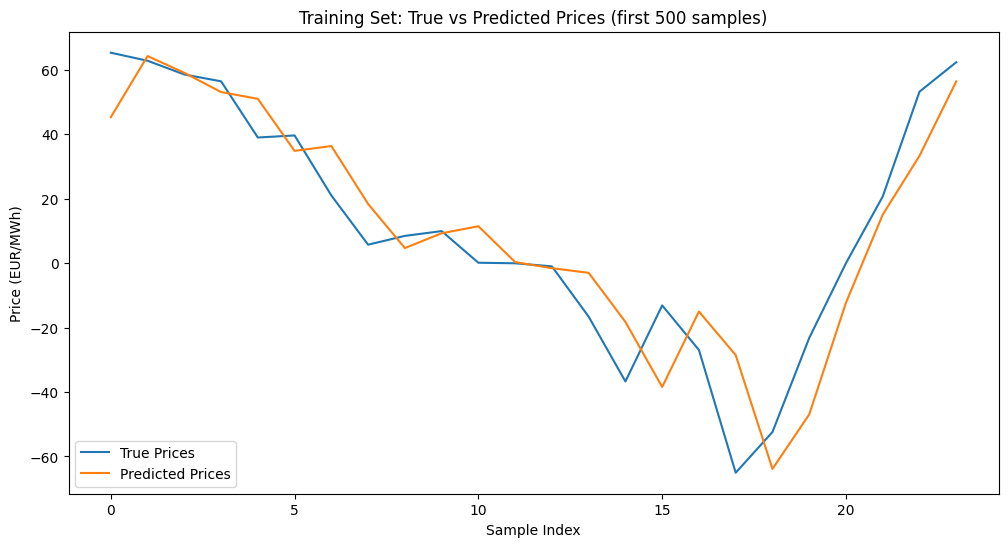

In [ ]:
#Plot on the training set
plt.figure(figsize=(12,6))
idx=np.random.randint(0, len(eval_res_train["true_prices"])-24)
plt.plot(eval_res_train["true_prices"][idx:idx+24], label="True Prices")
plt.plot(eval_res_train["predicted_prices"][idx:idx+24], label="Predicted Prices")
plt.title("Training Set: True vs Predicted Prices (first 500 samples)")
plt.xlabel("Sample Index")
plt.ylabel("Price (EUR/MWh)")
plt.legend()
plt.show()

In [ ]:
def objective(trial):
    # --- Hyperparameters to tune ---
    hidden_size=trial.suggest_categorical("hidden_size", [64, 128, 256])
    num_layers=trial.suggest_categorical("num_layers", [1, 2, 3])
    dropout = trial.suggest_float("dropout", 0.0, 0.5)
    use_batchnorm = trial.suggest_categorical("use_batchnorm", [True, False])
    leaky_alpha = trial.suggest_float("leaky_alpha", 0.0, 0.2)
    learning_rate = trial.suggest_loguniform("learning_rate", 1e-5, 1e-2)
    weight_decay = trial.suggest_loguniform("weight_decay", 1e-6, 1e-3)
    l1_lambda = trial.suggest_loguniform("l1_lambda", 1e-7, 1e-3)
    batch_size = trial.suggest_categorical("batch_size", [64, 128, 256])
    epochs = 20  # you can reduce for faster search
    huber_delta = trial.suggest_float("huber_delta", 0.5, 5.0)

    # --- Train model ---
    MODEL, train_hist, val_hist = run_full_train(
        X_seq_train, y_train, X_seq_dev, y_dev,
        hidden_size=hidden_size,
        num_layers=num_layers,
        dropout=dropout,
        use_batchnorm=use_batchnorm,
        leaky_alpha=leaky_alpha,
        learning_rate=learning_rate,
        weight_decay=weight_decay,
        l1_lambda=l1_lambda,
        batch_size=batch_size,
        epochs=epochs,
        verbose_freq=10,
        huber_delta=huber_delta,
        device=device
    )

    # --- Evaluate on dev set ---
    metrics = evaluate_model(MODEL, X_seq_dev, price_dev, price_1d_dev, price_7d_dev, price_std, price_mean, pct_mean, pct_std, device=device)
    mae=metrics["MAE"]
    maem=metrics["MAEm"]
    rmae_1d=metrics["rMAE (1 day)"]  # smaller = better
    rmae_7d=metrics["rMAE (7 days)"]  # smaller = better

    return mae,maem, rmae_1d, rmae_7d
# --- Run the study ---
study = optuna.create_study(directions=["minimize","minimize","minimize","minimize"])    
study_name="FR_LMP_MLP"
study.optimize(objective, n_trials=20, timeout=None)

best_trials = study.best_trials
print(f"Found {len(best_trials)} Pareto-optimal trials.")

for t in best_trials:
    print(f"Values: {t.values}")
    print(f"Params: {t.params}")



[I 2025-11-27 01:45:01,785] A new study created in memory with name: no-name-b89ed521-a491-48e5-b693-af7b8d1df2d8


SimpleRNN(
  (lstm): LSTM(10, 128, num_layers=3, batch_first=True, dropout=0.34410833243672817)
  (dropout): Dropout(p=0.34410833243672817, inplace=False)
  (fc1): Linear(in_features=128, out_features=128, bias=True)
  (fc2): Linear(in_features=128, out_features=1, bias=True)
)


/tmp/ipykernel_5457/1450441565.py:8: FutureWarning: suggest_loguniform has been deprecated in v3.0.0. This feature will be removed in v6.0.0. See https://github.com/optuna/optuna/releases/tag/v3.0.0. Use suggest_float(..., log=True) instead.
  learning_rate = trial.suggest_loguniform("learning_rate", 1e-5, 1e-2)
/tmp/ipykernel_5457/1450441565.py:9: FutureWarning: suggest_loguniform has been deprecated in v3.0.0. This feature will be removed in v6.0.0. See https://github.com/optuna/optuna/releases/tag/v3.0.0. Use suggest_float(..., log=True) instead.
  weight_decay = trial.suggest_loguniform("weight_decay", 1e-6, 1e-3)
/tmp/ipykernel_5457/1450441565.py:10: FutureWarning: suggest_loguniform has been deprecated in v3.0.0. This feature will be removed in v6.0.0. See https://github.com/optuna/optuna/releases/tag/v3.0.0. Use suggest_float(..., log=True) instead.
  l1_lambda = trial.suggest_loguniform("l1_lambda", 1e-7, 1e-3)
[W 2025-11-27 01:45:07,148] Trial 0 failed with parameters: {'hidde

KeyboardInterrupt: 